# Deep Embedded Clustering (DEC) algorithm from the paper “Unsupervised Deep Embedding for Clustering Analysis” by Xie et al. (2016)

    •	Autoencoder pretraining builds meaningful feature representations.
	•	Student’s t-distribution defines soft assignment probabilities.
	•	Auxiliary distribution boosts confident assignments and normalizes cluster contribution.
	•	KL divergence minimization drives the optimization.
	•	End-to-end training updates both the encoder and centroids together.

### STEP 1 — Autoencoder Pretraining

Trains a stacked denoising autoencoder on input data.

This section implements a **greedy layer-wise pretraining** procedure for a deep autoencoder, followed by **end-to-end fine-tuning**.  
The final result is an encoder that maps input data into a compact latent space, ready for downstream tasks like clustering.

The implementation details now live in `dec_model.py`. The notebook keeps the same step-by-step structure and diagnostics, but imports the reusable classes and functions from that file.

---

### 🔧 Configuration
- **Device (`DEVICE`)**: Uses GPU if available, otherwise CPU  
- **Batch size (`BATCH_SIZE`)**: Controls how many samples are processed at once  
- **Learning rate (`LEARNING_RATE`)**: Step size for optimization  
- **Epochs**:  
  - `PRETRAIN_EPOCHS`: greedy layer-wise pretraining iterations per layer
  - `FINETUNE_EPOCHS`: number of iterations for full autoencoder fine-tuning  

---

### 1. Denoising Autoencoder (DAE)

An autoencoder is trained to reconstruct the input, assuming comes from a noisy version, compressing and then decompressing the data. Used for greedy layer-wise pretraining.

- **Purpose**: Trains each layer to reconstruct its input from a noisy version  
- **Structure**:  
  - **Encoder**: Linear transformation to reduce dimensionality  
  - **Decoder**: Linear transformation to reconstruct the original input  
- **Activation**: ReLU applied after encoding, except the final latent layer by default  
- **Loss function**: Mean Squared Error (MSE) between input and reconstruction  

This is the building block for greedy pretraining.

---

### 2. Stacked Encoder

Used to forward data through pretrained encoder layers.

- A container for a variable number of linear encoder layers  
- Built using `nn.ModuleList` so all layers are properly registered for:
  - Parameter optimization
  - Device transfers (`.to(DEVICE)`)
  - Saving/loading via `state_dict`  
- Applies activation inside the encoder `forward()` method, so the trained nonlinear mapping is preserved  

`StackedEncoder` / `Encoder` constructs a sequence of `nn.Linear` layers defined by the dimensions.
`nn.ModuleList` is used to register the layers as submodules, which ensures that their parameters
are included in `model.parameters()`, handled by `.to(device)`, and saved via `state_dict()`.
Unlike a plain Python list, `ModuleList` integrates with PyTorch’s internal module tracking system,
enabling proper parameter optimization and recursive operations.
Any time you want to manage a variable number of layers or modules, use `nn.ModuleList`
(or `nn.Sequential` if the sequential container itself fully defines the forward pass you need).

---

### 3. Greedy Layer-Wise Pretraining
1. For each target hidden dimension in `layer_dims`:
   - Train a shallow DAE on the current input  
   - Add Gaussian noise to inputs (denoising)  
   - Optimize with Adam using MSE loss  
2. After training:
   - Freeze the encoder part  
   - Transform the dataset with the trained encoder  
   - Use the transformed dataset as input for the next layer  
3. Store all encoder layers in sequence  

This builds progressively more abstract latent representations and returns the encoder needed for clustering.

---

### 4. Full Autoencoder Assembly
- **Encoder**: `Encoder` module containing all pretrained encoder layers and activations  
- **Decoder**: Built by reversing the encoder architecture  
- **Forward pass**:
  - Encode through the learned nonlinear mapping  
  - Decode through the mirrored decoder, leaving the final reconstruction layer unclipped  

---

### 5. End-to-End Fine-Tuning
- Instantiate the full autoencoder  
- Train on the original dataset to minimize reconstruction error  
- Shuffling data each epoch improves generalization  
- After training:
  - Switch encoder to inference mode (`.eval()`)  
  - Use encoder for extracting latent representations  

---

### 6. Diagnostic Preview
- Use `torch.no_grad()` for efficiency (no gradients tracked)  
- Preview the shape, mean, and standard deviation of latent outputs for a sample batch  

---

✅ **Outcome**: A pretrained encoder that maps high-dimensional input data into a compact latent space, robust and ready for clustering.  


In [28]:
# pip install torch
import os

# Keep native numerical libraries conservative inside the notebook.
# This should run before importing torch, sklearn, numba, or umap.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMBA_NUM_THREADS", "1")

import numpy as np
import torch
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from dec_model import (
    BATCH_SIZE,
    DEVICE,
    FINETUNE_EPOCHS,
    LEARNING_RATE,
    PRETRAIN_EPOCHS,
    DECTrainingResult,
    DenoisingAutoencoder,
    Encoder,
    FullAutoencoder,
    StackedEncoder,
    compute_soft_assignments,
    compute_target_distribution,
    encode_dataset,
    initialize_clusters,
    kl_loss,
    plot_final_tsne,
    plot_tsne,
    pretrain_autoencoder,
    train_DEC,
)


In [29]:
# ---- Config ----
# The DEC classes and functions are imported from dec_model.py.
# Keeping the configuration here makes the notebook easier to read and keeps
# the paper-like flow: pretrain -> initialize clusters -> compute Q/P -> train DEC.

LAYER_DIMS = [500, 500, 2000, 10]
N_CLUSTERS = 10

print(f"Using device: {DEVICE}")
print(f"Layer dimensions: {LAYER_DIMS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Pretrain epochs per layer: {PRETRAIN_EPOCHS}")
print(f"Fine-tune epochs: {FINETUNE_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")


Using device: cpu
Layer dimensions: [500, 500, 2000, 10]
Batch size: 256
Pretrain epochs per layer: 10
Fine-tune epochs: 20
Learning rate: 0.001


The variable `encoder` stores the trained encoder model returned by `pretrain_autoencoder()`.
This model is an `Encoder` object imported from `dec_model.py`: it contains the trained linear layers and the activation logic in its `forward()` method.

Later, when we write `encoder(X_tensor)`, we're calling the model on input data.
In PyTorch, models are callable: calling them triggers their `forward()` method as implemented in the `__call__()` method.

Even though we use the same name `encoder` inside and outside the function, there's no conflict:
the function's `encoder` is a local variable, and we just reuse the name when assigning the return value.
This is standard Python behavior and helps keep the code readable and intuitive.


In [30]:
# Simulate data
np.random.seed(42)
torch.manual_seed(42)
X = np.random.rand(10000, 784).astype(np.float32)

# Pretrain encoder
# Return the encoder model, including its linear layers and activation behavior.
encoder = pretrain_autoencoder(
    X,
    layer_dims=LAYER_DIMS,
    batch_size=BATCH_SIZE,
    pretrain_epochs=PRETRAIN_EPOCHS,
    finetune_epochs=FINETUNE_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
)


### Diagnosis

# Encode the full dataset after pretraining.
# Z is kept as a tensor because the next diagnostic markdown originally talks
# about torch.Size([10000, 10]); Z_np is the NumPy copy used by plotting tools.
Z_np = encode_dataset(encoder, X, batch_size=BATCH_SIZE, device=DEVICE)
Z = torch.tensor(Z_np, dtype=torch.float32, device=DEVICE)
print(Z.shape)

# Expected output: torch.Size([10000, 10])



Starting Autoencoder Pretraining
Initial input shape: (10000, 784)

Pretraining Layer 1: 784 -> 500
   Epoch  1 | Reconstruction Loss: 0.105485
   Epoch 10 | Reconstruction Loss: 0.077894
Output shape after Layer 1: torch.Size([10000, 500])

Pretraining Layer 2: 500 -> 500
   Epoch  1 | Reconstruction Loss: 0.015588
   Epoch 10 | Reconstruction Loss: 0.005877
Output shape after Layer 2: torch.Size([10000, 500])

Pretraining Layer 3: 500 -> 2000
   Epoch  1 | Reconstruction Loss: 0.004464
   Epoch 10 | Reconstruction Loss: 0.000782
Output shape after Layer 3: torch.Size([10000, 2000])

Pretraining Layer 4: 2000 -> 10
   Epoch  1 | Reconstruction Loss: 0.035042
   Epoch 10 | Reconstruction Loss: 0.000095
Output shape after Layer 4: torch.Size([10000, 10])

Fine-tuning full autoencoder
   Epoch  1 | Fine-tune Loss: 0.135701
   Epoch  5 | Fine-tune Loss: 0.083411
   Epoch 10 | Fine-tune Loss: 0.083391
   Epoch 15 | Fine-tune Loss: 0.083445
   Epoch 20 | Fine-tune Loss: 0.083410

Final enc

The autoencoder pretraining has successfully compressed the original 784-dimensional input space into a 10-dimensional latent representation (torch.Size([10000, 10])) through a series of progressively deeper layers. The decreasing reconstruction loss across both the greedy layer-wise pretraining and the full fine-tuning phases indicates that the network has learned increasingly abstract and effective intermediate representations of the data.
	•	Layer-wise behavior:
The most dramatic drop in reconstruction error occurs in the early layers (e.g., 784 → 500), which capture the low-level structure of the input. Later layers (e.g., 500 → 2000 → 10) maintain very low reconstruction error, suggesting that higher-level, compact encodings are being successfully formed without significant information loss.
	•	Latent space diagnostics:
The final encoder output has shape (10000, 10), as expected. However, the mean values are quite negative and non-centered, and standard deviations are very small (~0.01–0.03). This low variance per dimension indicates a potential collapse of the latent space, where the encoded representations do not sufficiently spread out. In clustering terms, this could lead to poor separation of clusters, since all samples are mapped into a narrow, nearly constant subspace.
	•	Fine-tuning plateau:
The fine-tuning loss decreases from ~0.39 to ~0.27 but then stagnates slightly. This suggests the encoder has reached a local minimum that captures structural regularities in the data, though further gain might require regularization, different activation functions, or batch normalization.

⸻

✅ Conclusion

The autoencoder structurally performs well and matches the expected output shape for DEC. However, the extremely low variance in the 10D latent space is a red flag for clustering: it suggests that the learned embeddings may not be sufficiently discriminative. Before proceeding to clustering, it’s advisable to inspect this behavior further — e.g., visualize with t-SNE or try alternative activations (e.g., tanh) or initialization schemes to encourage richer variance across latent dimensions.

#### STEP 1.1 — UMAP / PCA Visual Check

UMAP (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique used to visualize and analyze high-dimensional data in a lower-dimensional space.

In this local environment, the UMAP stack can hard-crash the notebook kernel because it goes through native `numba` / OpenMP code. The warning
`n_jobs value 1 overridden to 1 by setting random_state` is harmless, and the `omp_set_nested` line is also only an OpenMP deprecation notice. The kernel restart is the real problem.

For that reason, the cell below uses PCA by default for the quick diagnostic plot. PCA is less manifold-aware than UMAP, but it is stable and still useful for checking whether the latent space has obvious spread or collapse. If the environment is stable after package fixes, set `VISUAL_METHOD = "umap"` in the next cell.

Technical Assumptions Behind UMAP:

1.	Data Lies on a Riemannian Manifold
	•	UMAP assumes the high-dimensional data points are sampled from a manifold — a smooth, curved geometric space embedded within the high-dimensional ambient space.
	•	This means local neighborhoods in the data are meaningful and reflect intrinsic geometric structure.

2.	Local Connectivity / Locality Structure Is Meaningful
	•	The relationships between a point and its nearest neighbors carry key information about the data structure.
	•	UMAP models these local relationships via a weighted graph (fuzzy simplicial complex).

3.	Metric Space Assumption
	•	The input data space is a metric space with a defined distance function (e.g., Euclidean distance).
	•	Distances meaningfully reflect similarity or dissimilarity.



If your latent space is collapsed, lacks variance, or poorly clustered, UMAP will typically show a dense blob or a random scatter without clear cluster structure. This is a strong indicator that the autoencoder pretraining or architecture needs tuning.
A well-structured latent space leads UMAP to produce a visually interpretable, clustered, and manifold-like projection that aligns with the underlying data semantics. Instead of isolated blobs, points may lie on continuous shapes or “curves” indicating smooth transitions between related data points. This suggests the autoencoder learned a latent space that respects intrinsic data geometry.


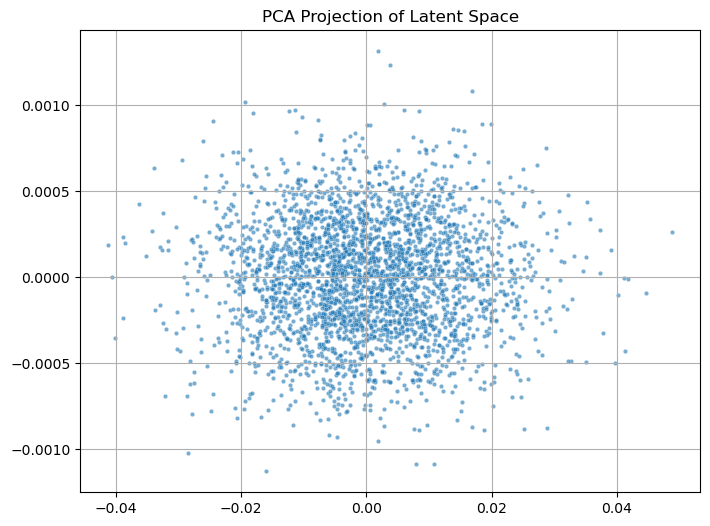

In [31]:
# Convert latent tensor Z from GPU to CPU and then to NumPy.
if isinstance(Z, torch.Tensor):
    Z_np = Z.detach().cpu().numpy()
else:
    Z_np = np.asarray(Z)

# Native UMAP crashes can restart the kernel before Python can catch an error.
# Keep PCA as the default stable visual diagnostic. Change to "umap" only after
# the local OpenMP/numba/UMAP environment is known to be stable.
VISUAL_METHOD = "pca"  # options: "pca", "umap"
MAX_VISUAL_POINTS = 3000

Z_visual_source = np.nan_to_num(Z_np).astype(np.float32, copy=False)
if len(Z_visual_source) > MAX_VISUAL_POINTS:
    rng = np.random.default_rng(42)
    visual_idx = np.sort(rng.choice(len(Z_visual_source), size=MAX_VISUAL_POINTS, replace=False))
    Z_visual_source = Z_visual_source[visual_idx]
else:
    visual_idx = np.arange(len(Z_visual_source))

if VISUAL_METHOD == "umap":
    import umap.umap_ as umap

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        low_memory=True,
        n_jobs=1,
        random_state=42,
    )
    Z_visual = reducer.fit_transform(Z_visual_source)
    visual_title = "UMAP Projection of Latent Space"
else:
    from sklearn.decomposition import PCA

    reducer = PCA(n_components=2, random_state=42)
    Z_visual = reducer.fit_transform(Z_visual_source)
    visual_title = "PCA Projection of Latent Space"

# Plot the 2D projection.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Z_visual[:, 0], y=Z_visual[:, 1], s=10, alpha=0.6)
plt.title(visual_title)
plt.grid(True)
plt.show()


### STEP 2 — Cluster Initialization

Transform the raw input data X into a latent representation Z using the pretrained encoder from Step 1, and then apply KMeans to initialize the cluster centroids {μ₁, ..., μ_k} using k-means for Deep Embedded Clustering (DEC).

This is critical because it seeds DEC with meaningful initial cluster positions in the embedded space.

In [32]:
# initialize_clusters(...) is imported from dec_model.py.
# This cell is kept here as the Step 2 implementation pointer so the notebook
# structure still follows the DEC paper: first encode X into Z, then run KMeans
# in that latent space to initialize the centroids mu.


In [33]:
# Step 1: Pretrain encoder
# encoder = pretrain_autoencoder(X, layer_dims=LAYER_DIMS)

# Step 2: Initialize clusters
Z, mu, kmeans_labels = initialize_clusters(
    encoder,
    X,
    k=N_CLUSTERS,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

# Sanity check
print("Z sample:", Z[:2])
print("mu sample:", mu[:2])



Running KMeans clustering on latent features...
Latent shape Z: (10000, 10)
Initial centroids mu: (10, 10)
Cluster size distribution: [1594 1269  735  513 1288 1628  170  286  904 1613]
Z sample: [[-0.34572664  0.23351163  0.35858816  0.03863092 -0.32218972  0.16996874
  -0.22886857 -0.23000091 -0.25155482 -0.18382475]
 [-0.35011697  0.23580575  0.3628788   0.03849045 -0.32577384  0.17123306
  -0.2316949  -0.23254468 -0.25438192 -0.18549164]]
mu sample: [[-0.35037047  0.23620725  0.3632498   0.03883237 -0.3260588   0.17166056
  -0.23192522 -0.232968   -0.2546305  -0.18579906]
 [-0.3430734   0.23174135  0.3559307   0.03806543 -0.3199786   0.16874602
  -0.22710426 -0.22816785 -0.24977958 -0.18229693]]


### Step 3 – Soft Assignment via Student’s t-Distribution


This step transforms each encoded point zᵢ and each cluster centroid μⱼ into a soft assignment probability qᵢⱼ, using the Student’s t-distribution as a kernel.

In DEC, qᵢⱼ is interpreted as the probability that sample i belongs to cluster j. Unlike hard KMeans assignments, these probabilities allow gradient-based learning in subsequent steps.

---

#### Step-by-Step Process

**Step 1 – Distance Matrix**  
Compute the full squared Euclidean distance matrix D of shape `(n_samples, n_clusters)`.  
Each entry $ D[i, j] $ is the squared distance between a latent vector zᵢ and centroid μⱼ.  
We use **NumPy broadcasting** instead of explicit nested loops for efficiency:


squared_dist = np.sum((Z[:, np.newaxis, :] - mu[np.newaxis, :, :])**2, axis=2)


**Step 2 – Convert Distances to Similarities**  
Apply the Student’s t-distribution kernel to convert distances into **unnormalized affinities**:

$$ 
q_{ij} \propto \left(1 + \frac{\|z_i - \mu_j\|^2}{\alpha}\right)^{-\frac{\alpha+1}{2}}
$$

- **Parameter $alpha$** controls the shape of the kernel:
  - $alpha = 1$: Cauchy-like kernel, heavy-tailed, tolerant of outliers  
  - Larger $alpha$: decays faster, closer to Gaussian  

**Step 3 – Normalize to Probabilities**  
Normalize row-wise so that each sample’s probabilities sum to 1
$Q[i, j] ≈$ probability of sample i belonging to cluster j

Q = unnormalized_affinity / np.sum(unnormalized_affinity, axis=1, keepdims=True)

--- 

#### Shape Evolution in Soft Assignment Computation

Think of the data flow as reshaping physical objects to make them fit together for interaction:

- **Latent space**
  - `Z`: (n_samples, latent_dim)  
    Each sample is a **point in latent space**, like particles in a 10‑dimensional box.  
  - `mu`: (n_clusters, latent_dim)  
    Each centroid is a **reference point** (like anchors) in the same box.

- **Broadcasting → Expanding dimensions**
  ```python
  squared_dist = np.sum((Z[:, np.newaxis, :] - mu[np.newaxis, :, :])**2, axis=2)

  
Parameter alpha controls how heavy tailed the distribution is.
alpha = 1 returns a Cauchy-like kerner that is very tolerant of outliers
Larger values of alpha make similarity drop faster (Gaussian-like kernel)saf

In [34]:
# compute_soft_assignments(...) is imported from dec_model.py.
# It implements the Student's t-distribution kernel from the DEC paper and
# returns Q, where each row is a probability distribution over clusters.


In [35]:
# Step 3: Soft Assignment
Q = compute_soft_assignments(Z, mu)


Computing soft assignments Q using Student's t-distribution...
Q shape: (10000, 10) (Rows = samples, Cols = clusters)
Q min/max: 0.099611 / 0.100265
Q row sums (should all be near 1): mean=1.0000, std=0.000000
Example soft assignments (first 3 rows):
[[0.10002264 0.10002904 0.0999795  0.10000032 0.10000703 0.10003056
  0.09995449 0.09992439 0.1000195  0.10003257]
 [0.10003663 0.10001414 0.10001712 0.09996376 0.1000319  0.10003468
  0.09989993 0.09997979 0.09999473 0.10002734]
 [0.10002619 0.10002523 0.0999891  0.09999099 0.10001337 0.10003161
  0.09994055 0.09993851 0.10001317 0.10003123]]


Expected behavior

Q.shape: (n_samples, k) — matches data and cluster count

Each row sums to 1 — valid probability distribution

Q values are soft, not hard — e.g., [0.1, 0.7, 0.05, ...]

Higher value means stronger assignment to that cluster

Q[:3]: Each row is a probability distribution over clusters

If all values are close to 0.1, the model is uncertain. If one value dominates, the model is confident.


### STEP 3.2 — Compute Target Distribution


In this step, we take the soft assignment matrix Q (from Step 3) and compute a sharpened target distribution P. This distribution places more emphasis on confident assignments and helps reinforce cluster purity during training.

Instead of treating Q as the optimization target, the DEC algorithm computes a modified P to pull embeddings toward high-confidence cluster centers.

In [36]:
# compute_target_distribution(...) is imported from dec_model.py.
# It squares Q to sharpen confident assignments, divides by soft cluster
# frequency to avoid letting large clusters dominate, and normalizes each row.


In [37]:
P = compute_target_distribution(Q)


Computing target distribution P...
P shape: (10000, 10) (same as Q)
P min/max: 0.099276 / 0.100600
P row sums (should all be near 1): mean=1.0000, std=0.000000
Example target assignments (first 3 rows):
[[0.10001664 0.10003509 0.0999649  0.10001608 0.09999786 0.10002664
  0.09997782 0.09990258 0.10003049 0.1000318 ]
 [0.10004463 0.10000531 0.10004015 0.09994298 0.1000476  0.10003487
  0.09986873 0.10001338 0.09998097 0.10002135]
 [0.10002377 0.1000275  0.09998412 0.09999745 0.10001057 0.10002875
  0.09994996 0.09993084 0.10001786 0.10002914]]


Expected behaviour

P.shape: Same as Q (n_samples × k)

P.min()/max(): Higher than Q (more peaked)

P row sums: All rows sum ≈ 1.0

P[:3]: Should have more extreme values (i.e. one cluster dominates more)


In this case: 
	•	min = 0.094489, max = 0.105084 — all values in P are very close to uniform distribution (1/10 = 0.10).
	•	Ideally, P should be more “peaky” than Q — it should amplify confident assignments (e.g., some values near 0.7 or 0.8 in strongly assigned clusters).

#### STEP 3.2.1 — TSNE Check


t-SNE (t-Distributed Stochastic Neighbor Embedding) reduces your high-dimensional latent space (e.g. 10D) into 2D while preserving local structure (i.e., neighbors stay neighbors). 
This is not a clustering algorithm, but a projection for visualization.
Each dot is a sample, positioned based on its similarity in the latent space Z.

🔎 How to Read It:

•	Well-separated colored blobs: ✅ encoder learned good structure.

•	Overlapping colors: ⚠️ centroids may be poorly placed, latent space too compressed.

In [38]:
# plot_tsne(...) is imported from dec_model.py.
# Keeping the plotting call in the notebook makes the diagnostic flow explicit,
# while the reusable plotting helper stays with the DEC utilities.



Running t-SNE...
t-SNE completed. Plotting...


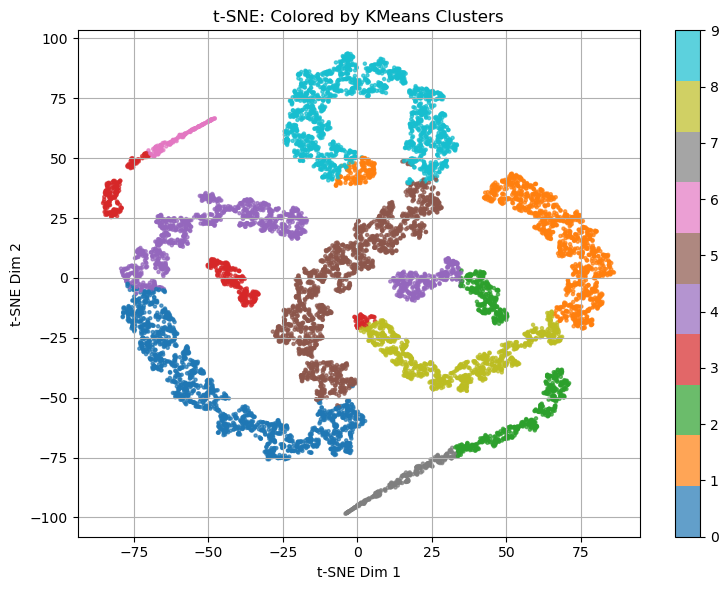

In [39]:
plot_tsne(Z, labels=kmeans_labels, title="t-SNE: Colored by KMeans Clusters")

What It Shows:

You color by the cluster with the highest soft assignment probability for each sample.
Based on Q from Step 3, which uses Student’s t-distribution — more sensitive to local distances than Euclidean.

How to Read It:

Same goal as KMeans, but potentially more adaptive to non-convex shapes.
If this matches KMeans coloring well → your centroids and kernel-based similarity agree.
If this differs → might suggest:
Some samples are close to multiple centroids (KMeans ambiguous)
Q sees structure that KMeans misses (non-linear shapes)



Running t-SNE...
t-SNE completed. Plotting...


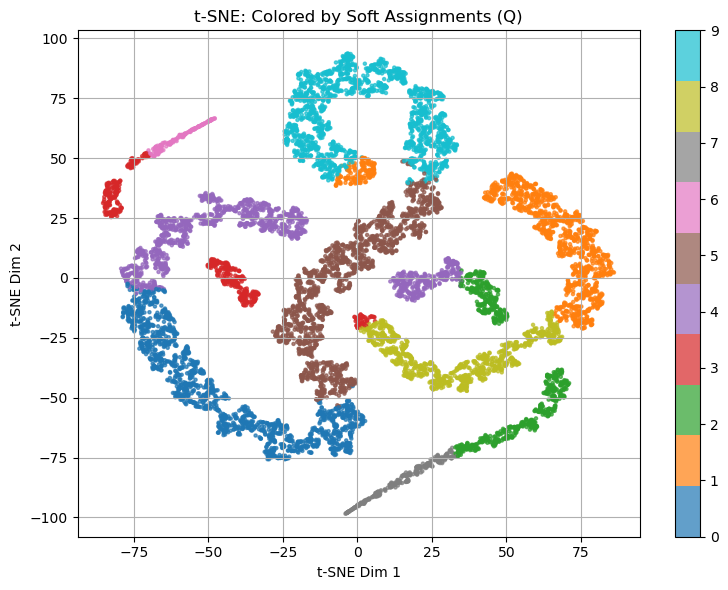

In [40]:
Q_labels = np.argmax(Q, axis=1)
plot_tsne(Z, labels=Q_labels, title="t-SNE: Colored by Soft Assignments (Q)")

### STEP 3.3 — KL Divergence Loss

Goal: Compute KL Divergence Between P and Q

The DEC algorithm updates the encoder by minimizing the KL divergence between the auxiliary target distribution P (sharpened assignments) and the current soft assignments Q.

This loss encourages the encoder to map samples into regions where confident cluster assignments (from P) are matched by the model’s actual assignments (Q).

In [41]:
# kl_loss(...) is imported from dec_model.py.
# It computes KL(P || Q) with small clamps for numerical stability.


In [42]:
# Convert from numpy to torch
P_torch = torch.tensor(P, dtype=torch.float32).to(DEVICE)
Q_torch = torch.tensor(Q, dtype=torch.float32).to(DEVICE)

# Compute KL divergence loss
loss = kl_loss(P_torch, Q_torch)
print(f"🔥 KL divergence loss: {loss.item():.6f}")

🔥 KL divergence loss: 0.000000


Value Range   ->   Interpretation

=> 1.0        ->   Poor match between P and Q — encoder and centroids are off.

~0.1          ->   Acceptable but indicates room for training.

0.01 – 0.001  ->   Very good — Q is nearly matching P, clusters are sharpening.

< 0.001       ->   Possibly perfect… or possibly flat P and Q (both uniform).


In [43]:
# Check Distribution of Q
# If all are close to 0.1 → Soft assignments are too flat.
print("Q max per sample (top 5):", torch.max(Q_torch, dim=1).values[:5].cpu().numpy())

Q max per sample (top 5): [0.10003257 0.10003663 0.10003161 0.10003198 0.10003433]


In [44]:
# Compare Entropy of P and Q
# Lower entropy means more confident predictions (sharper distributions).
# Ideally: P should be sharper (lower entropy) than Q.

entropy_P = -torch.sum(P_torch * torch.log(P_torch), dim=1).mean()
entropy_Q = -torch.sum(Q_torch * torch.log(Q_torch), dim=1).mean()
print(f"P entropy: {entropy_P.item():.4f} | Q entropy: {entropy_Q.item():.4f}")

P entropy: 2.3026 | Q entropy: 2.3026


### Step 3.4 — Training Step
Fine-tune the encoder so that it learns to shape the latent space Z in a way that improves cluster assignment
by minimizing the KL divergence loss.

This is done iteratively:

1.	Forward pass to compute Z → Q

2.	Compute target distribution P from Q

3.	Compute KL(P‖Q) loss

4.	Backpropagate loss through the encoder and the cluster centroids

5.	Update parameters

6.	Refresh P every few epochs and repeat until convergence or `max_epochs`


In [45]:
# train_DEC(...) is imported from dec_model.py.
# The implementation fine-tunes the encoder and treats the centroids as trainable
# parameters, matching the paper's KL divergence minimization phase more closely
# than freezing mu after KMeans.


In [46]:
Z, mu, kmeans_labels = initialize_clusters(
    encoder,
    X,
    k=N_CLUSTERS,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

dec_result = train_DEC(
    encoder,
    X,
    mu,
    batch_size=BATCH_SIZE,
    max_epochs=20,
    update_interval=5,
    lr=LEARNING_RATE,
    device=DEVICE,
)

# train_DEC mutates encoder in place and returns the updated centroids/labels
# so later diagnostics use the DEC-trained state, not the old KMeans centroids.
encoder = dec_result.encoder
mu = dec_result.centroids
dec_labels = dec_result.labels
loss_history = dec_result.loss_history



Running KMeans clustering on latent features...
Latent shape Z: (10000, 10)
Initial centroids mu: (10, 10)
Cluster size distribution: [1594 1269  735  513 1288 1628  170  286  904 1613]
Epoch  1 | KL Loss: 0.000008
Epoch  2 | KL Loss: 0.000001
Epoch  3 | KL Loss: 0.000001
Epoch  4 | KL Loss: 0.000001
Epoch  5 | KL Loss: 0.000000
   Target refresh | changed labels: 0.755400
Epoch  6 | KL Loss: 0.000000
Epoch  7 | KL Loss: 0.000000
Epoch  8 | KL Loss: 0.000000
Epoch  9 | KL Loss: 0.000000
Epoch 10 | KL Loss: 0.000000
   Target refresh | changed labels: 0.003600
Epoch 11 | KL Loss: 0.000000
Epoch 12 | KL Loss: 0.000000
Epoch 13 | KL Loss: 0.000000
Epoch 14 | KL Loss: 0.000000
Epoch 15 | KL Loss: 0.000000
   Target refresh | changed labels: 0.002900
Epoch 16 | KL Loss: 0.000000
Epoch 17 | KL Loss: 0.000000
Epoch 18 | KL Loss: 0.000000
Epoch 19 | KL Loss: 0.000000
Epoch 20 | KL Loss: 0.000000
DEC training complete.


### Final t-SNE Visualization of DEC Embeddings

At this point the encoder has been fine-tuned with the DEC objective. The next plot is a final visual sanity check: we encode the same `X` again, then project the learned latent vectors to two dimensions.

The important thing to remember is that t-SNE is only a visualization. It does not prove that the clustering is correct, but it can reveal whether the final embedding has visible groups, collapsed regions, or strange artifacts that deserve more inspection.


Running t-SNE on final embeddings...


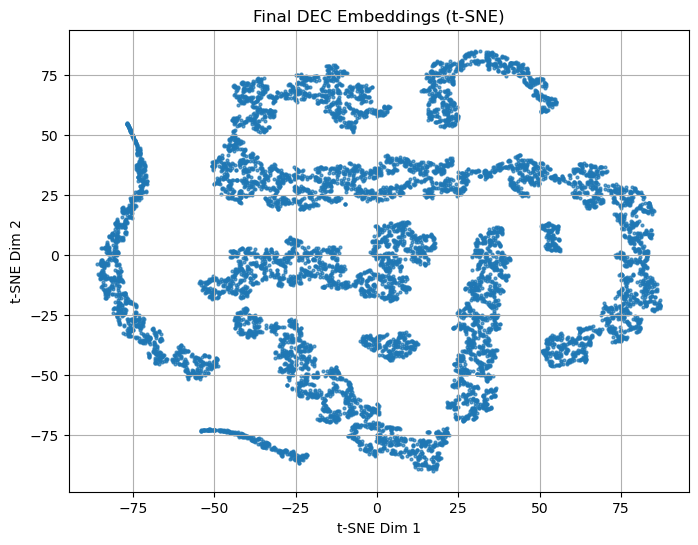

In [47]:
Z_final = plot_final_tsne(encoder, X)

In [48]:
# Optional Diagnostics After Training to assess if Q is sharp or too uniform

Z_after_dec = encode_dataset(encoder, X, batch_size=BATCH_SIZE, device=DEVICE)
Q_np = compute_soft_assignments(Z_after_dec, mu)
max_probs = Q_np.max(axis=1)

print("Q confidence stats:")
print("Min:", np.min(max_probs))
print("Max:", np.max(max_probs))
print("Mean:", np.mean(max_probs))



Computing soft assignments Q using Student's t-distribution...
Q shape: (10000, 10) (Rows = samples, Cols = clusters)
Q min/max: 0.099789 / 0.100275
Q row sums (should all be near 1): mean=1.0000, std=0.000000
Example soft assignments (first 3 rows):
[[0.10001236 0.10003277 0.10000306 0.09998036 0.10001621 0.10001264
  0.09992347 0.09995562 0.10000958 0.1000539 ]
 [0.10004294 0.10001082 0.0999944  0.0999874  0.10002261 0.10005116
  0.0999329  0.09994303 0.10000683 0.100008  ]
 [0.10001694 0.10002944 0.10000162 0.09998159 0.10001707 0.10001844
  0.09992515 0.0999537  0.10000926 0.10004675]]
Q confidence stats:
Min: 0.100031264
Max: 0.10027518
Mean: 0.10007671


## PART 1B — A Full DEC Pipeline on a Classic Dataset: Digits

The random dataset above is useful because it lets us inspect every mathematical step without worrying about labels or domain details. But random pixels do not contain real cluster structure, so the result is not a meaningful test of whether DEC can discover semantic groups.

Here we repeat the same DEC workflow on the classic `sklearn` digits dataset. It is a small handwritten-digit dataset with 8×8 grayscale images. It is not the full MNIST dataset, but it has the same spirit: each row is an image, and each image belongs to one of ten digit classes.

Important point: the labels are used only for evaluation after clustering. DEC itself still trains as an unsupervised method.


In [49]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import adjusted_rand_score, confusion_matrix, normalized_mutual_info_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import linear_sum_assignment

# Load a classic handwritten-digits dataset.
digits = load_digits()
X_digits_raw = digits.data.astype(np.float32)
y_digits = digits.target.astype(int)
digits_images = digits.images

# A compact preprocessing pipeline:
# 1. MinMaxScaler keeps values in [0, 1], similar to normalized image pixels.
# 2. VarianceThreshold removes pixels that never change across the dataset.
digits_preprocess = Pipeline(
    steps=[
        ("scale_to_unit_interval", MinMaxScaler()),
        ("drop_constant_pixels", VarianceThreshold(threshold=0.0)),
    ]
)
X_digits = digits_preprocess.fit_transform(X_digits_raw).astype(np.float32)

print("Raw digits shape:", X_digits_raw.shape)
print("Preprocessed digits shape:", X_digits.shape)
print("Number of true digit classes:", len(np.unique(y_digits)))
print("Pixel value range after preprocessing:", (X_digits.min(), X_digits.max()))


Raw digits shape: (1797, 64)
Preprocessed digits shape: (1797, 61)
Number of true digit classes: 10
Pixel value range after preprocessing: (0.0, 1.0)


### Digits Step 1 — Look at the Data Before Clustering

Before training any model, it helps to look at the input. Each image is only 8×8 pixels, so the data is much smaller than modern MNIST images. That makes it a good portfolio example: it runs quickly, is easy to explain, and still has real visual classes.

The model will not see these labels during training. The labels are shown here so we can understand the dataset and later evaluate whether the unsupervised clusters align with actual digit identities.


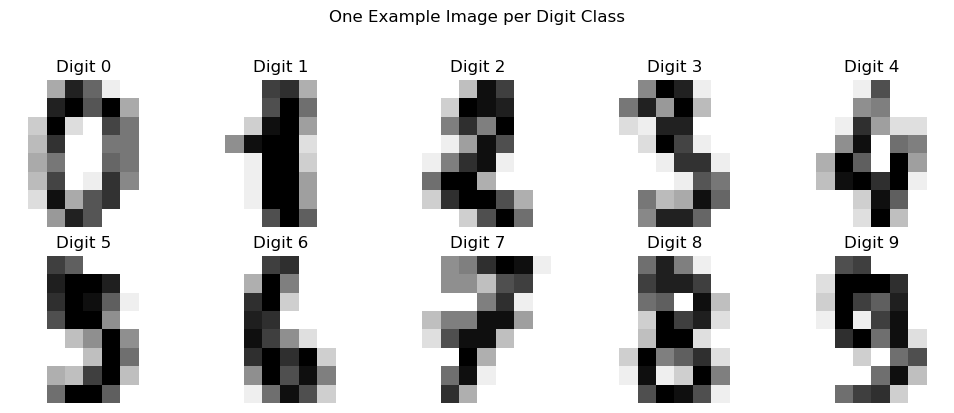

In [50]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit_value, ax in enumerate(axes.ravel()):
    first_idx = np.where(y_digits == digit_value)[0][0]
    ax.imshow(digits_images[first_idx], cmap="gray_r")
    ax.set_title(f"Digit {digit_value}")
    ax.axis("off")

plt.suptitle("One Example Image per Digit Class", y=1.02)
plt.tight_layout()
plt.show()


### Digits Step 2 — Define the DEC Pipeline

For this dataset, the full workflow is:

1. Load the images as tabular vectors.
2. Scale the pixel values to a stable numeric range.
3. Pretrain an autoencoder to compress each image into a lower-dimensional representation.
4. Run KMeans in that latent space to initialize cluster centers.
5. Fine-tune the encoder and centroids with DEC's KL-divergence objective.
6. Evaluate the final clusters against labels that were not used during training.

The architecture is smaller than the random 784-dimensional example because the digits dataset has far fewer input features.


In [51]:
DIGITS_LAYER_DIMS = [128, 64, 10]
DIGITS_N_CLUSTERS = 10
DIGITS_BATCH_SIZE = 128
DIGITS_PRETRAIN_EPOCHS = 8
DIGITS_FINETUNE_EPOCHS = 12
DIGITS_DEC_EPOCHS = 25

print("Digits DEC configuration")
print("Input dimension:", X_digits.shape[1])
print("Layer dimensions:", DIGITS_LAYER_DIMS)
print("Clusters:", DIGITS_N_CLUSTERS)
print("Batch size:", DIGITS_BATCH_SIZE)


Digits DEC configuration
Input dimension: 61
Layer dimensions: [128, 64, 10]
Clusters: 10
Batch size: 128


In [52]:
# Step 1: autoencoder pretraining on real handwritten-digit data.
digits_encoder = pretrain_autoencoder(
    X_digits,
    layer_dims=DIGITS_LAYER_DIMS,
    batch_size=DIGITS_BATCH_SIZE,
    pretrain_epochs=DIGITS_PRETRAIN_EPOCHS,
    finetune_epochs=DIGITS_FINETUNE_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
)

# Step 2: initialize DEC clusters with KMeans in the pretrained latent space.
digits_Z_init, digits_mu_init, digits_kmeans_labels = initialize_clusters(
    digits_encoder,
    X_digits,
    k=DIGITS_N_CLUSTERS,
    batch_size=DIGITS_BATCH_SIZE,
    device=DEVICE,
)

# Step 3: run the DEC refinement phase.
digits_dec_result = train_DEC(
    digits_encoder,
    X_digits,
    digits_mu_init,
    batch_size=DIGITS_BATCH_SIZE,
    max_epochs=DIGITS_DEC_EPOCHS,
    update_interval=5,
    lr=LEARNING_RATE,
    tol=0.001,
    device=DEVICE,
)

digits_encoder = digits_dec_result.encoder
digits_mu = digits_dec_result.centroids
digits_dec_labels = digits_dec_result.labels
digits_loss_history = digits_dec_result.loss_history
digits_Z_final = encode_dataset(digits_encoder, X_digits, batch_size=DIGITS_BATCH_SIZE, device=DEVICE)

print("Final digits latent shape:", digits_Z_final.shape)



Starting Autoencoder Pretraining
Initial input shape: (1797, 61)

Pretraining Layer 1: 61 -> 128
   Epoch  1 | Reconstruction Loss: 0.188082
   Epoch  8 | Reconstruction Loss: 0.030032
Output shape after Layer 1: torch.Size([1797, 128])

Pretraining Layer 2: 128 -> 64
   Epoch  1 | Reconstruction Loss: 0.115948
   Epoch  8 | Reconstruction Loss: 0.014957
Output shape after Layer 2: torch.Size([1797, 64])

Pretraining Layer 3: 64 -> 10
   Epoch  1 | Reconstruction Loss: 0.192968
   Epoch  8 | Reconstruction Loss: 0.028447
Output shape after Layer 3: torch.Size([1797, 10])

Fine-tuning full autoencoder
   Epoch  1 | Fine-tune Loss: 0.175639
   Epoch  5 | Fine-tune Loss: 0.067868
   Epoch 10 | Fine-tune Loss: 0.040433
   Epoch 12 | Fine-tune Loss: 0.036443

Final encoder output sample:
   Shape: (10, 10)
   Mean per latent dim: [ 1.8443501   0.5548155  -2.2147236   1.4053247   1.3243862  -0.47177583
 -0.64519763  0.06456095  2.63089     1.046623  ]
   Std per latent dim:  [0.3864711  0.7

### Digits Step 3 — Evaluate the Clusters

Clustering labels are arbitrary. For example, DEC cluster `0` does not automatically mean digit `0`. A cluster might correspond to digit `7`, digit `3`, or a mixture of several digits.

That is why we use three complementary metrics:

- **Adjusted Rand Index (ARI)**: compares pairs of samples and corrects for chance.
- **Normalized Mutual Information (NMI)**: measures shared information between clusters and true labels.
- **Hungarian matched accuracy**: finds the best one-to-one mapping between cluster IDs and digit labels, then reports accuracy.

The first two are standard clustering metrics. The matched accuracy is intuitive for a ten-class digit example, but it should be interpreted carefully because it uses the labels after training.


In [53]:
def clustering_accuracy_from_labels(y_true, y_pred):
    """
    Computes clustering accuracy after finding the best mapping from cluster IDs
    to true labels. This is only for evaluation; DEC never uses y_true to train.
    """
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    accuracy = cm[row_ind, col_ind].sum() / cm.sum()
    cluster_to_label = {cluster: label for label, cluster in zip(row_ind, col_ind)}
    aligned_pred = np.array([cluster_to_label.get(cluster, -1) for cluster in y_pred])
    return accuracy, cluster_to_label, aligned_pred, cm

# Evaluate KMeans initialization and final DEC assignments side by side.
digits_kmeans_acc, digits_kmeans_map, digits_kmeans_aligned, digits_kmeans_cm = clustering_accuracy_from_labels(
    y_digits,
    digits_kmeans_labels,
)
digits_dec_acc, digits_cluster_to_label, digits_aligned_labels, digits_dec_cm = clustering_accuracy_from_labels(
    y_digits,
    digits_dec_labels,
)

digits_metrics = pd.DataFrame(
    [
        {
            "stage": "KMeans on pretrained Z",
            "ARI": adjusted_rand_score(y_digits, digits_kmeans_labels),
            "NMI": normalized_mutual_info_score(y_digits, digits_kmeans_labels),
            "matched_accuracy": digits_kmeans_acc,
        },
        {
            "stage": "DEC refined clusters",
            "ARI": adjusted_rand_score(y_digits, digits_dec_labels),
            "NMI": normalized_mutual_info_score(y_digits, digits_dec_labels),
            "matched_accuracy": digits_dec_acc,
        },
    ]
)

display(digits_metrics.style.format({"ARI": "{:.3f}", "NMI": "{:.3f}", "matched_accuracy": "{:.3f}"}))
print("Cluster -> digit mapping learned only for evaluation:", digits_cluster_to_label)


,stage,ARI,NMI,matched_accuracy
0,KMeans on pretrained Z,0.491,0.602,0.634
1,DEC refined clusters,0.552,0.659,0.676


Cluster -> digit mapping learned only for evaluation: {6: 0, 5: 1, 2: 2, 0: 3, 4: 4, 1: 5, 7: 6, 9: 7, 3: 8, 8: 9}


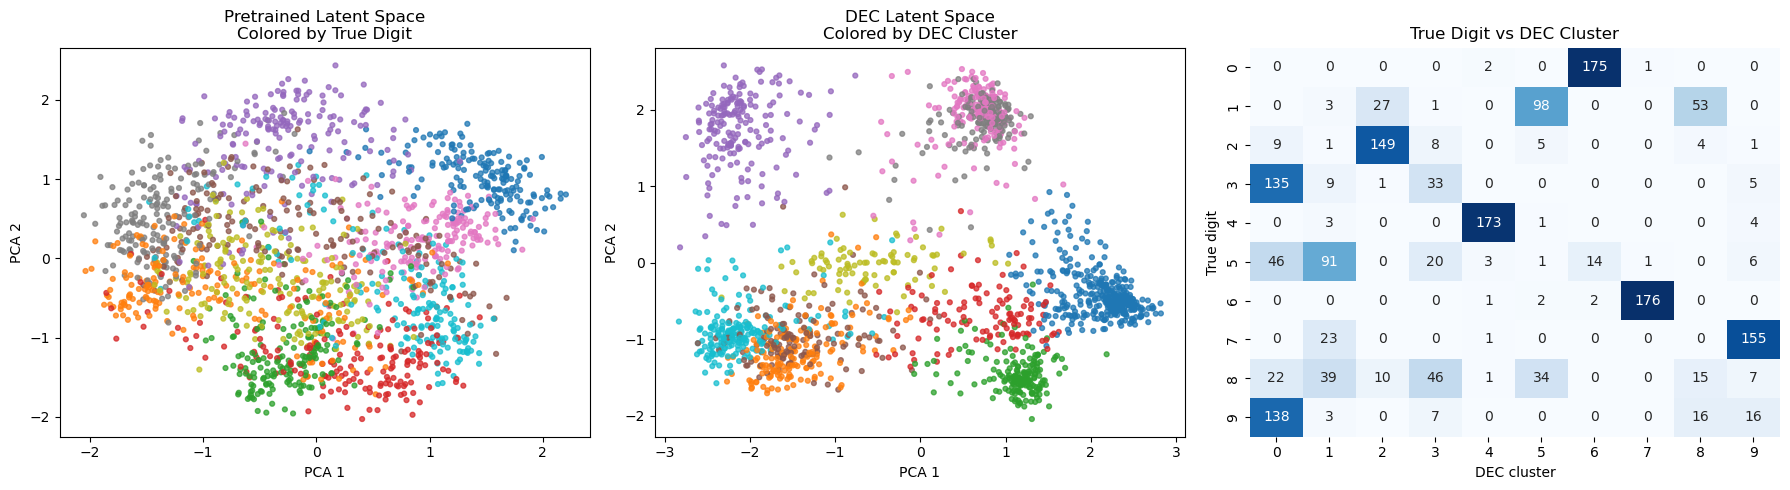

In [54]:
# Visualize the before/after embeddings with PCA for a stable, notebook-friendly plot.
digits_projection_model = PCA(n_components=2, random_state=42)
digits_Z_init_2d = digits_projection_model.fit_transform(digits_Z_init)
digits_Z_final_2d = PCA(n_components=2, random_state=42).fit_transform(digits_Z_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter0 = axes[0].scatter(
    digits_Z_init_2d[:, 0],
    digits_Z_init_2d[:, 1],
    c=y_digits,
    cmap="tab10",
    s=12,
    alpha=0.75,
)
axes[0].set_title("Pretrained Latent Space\nColored by True Digit")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

scatter1 = axes[1].scatter(
    digits_Z_final_2d[:, 0],
    digits_Z_final_2d[:, 1],
    c=digits_dec_labels,
    cmap="tab10",
    s=12,
    alpha=0.75,
)
axes[1].set_title("DEC Latent Space\nColored by DEC Cluster")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

sns.heatmap(digits_dec_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("True Digit vs DEC Cluster")
axes[2].set_xlabel("DEC cluster")
axes[2].set_ylabel("True digit")

plt.tight_layout()
plt.show()


### Digits Step 4 — Read the Result Like a Clustering Practitioner

A good DEC result should improve or at least preserve the structure found by KMeans initialization. On a small dataset, the gain may be modest because KMeans on autoencoder features can already be strong.

The useful diagnostic question is not only “did the score go up?” but also:

- Are some digits consistently mixed together?
- Are the clusters balanced or dominated by a few groups?
- Are soft assignments becoming more confident after DEC?
- Which latent dimensions actually separate the clusters?

The next section answers the last question in detail.


### Save and Reload the Random-Data Encoder

This small persistence check saves the first DEC encoder from the random-data walkthrough. The reloaded model is stored as `reloaded_encoder` so it does not overwrite the active `encoder` variable used earlier in the notebook.


In [55]:
# Save encoder for reuse
torch.save(encoder.state_dict(), "dec_encoder_final.pt")
print("💾 Encoder model saved to dec_encoder_final.pt")

💾 Encoder model saved to dec_encoder_final.pt


In [56]:
# Code to reload the encoder without overwriting the active notebook encoder.
# This is useful when you want to compare a saved model with the current model.
reloaded_encoder = Encoder(input_dim=X.shape[1], layer_dims=LAYER_DIMS).to(DEVICE)
reloaded_encoder.load_state_dict(torch.load("dec_encoder_final.pt", map_location=DEVICE))
reloaded_encoder.eval()


Encoder(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=500, bias=True)
    (1): Linear(in_features=500, out_features=500, bias=True)
    (2): Linear(in_features=500, out_features=2000, bias=True)
    (3): Linear(in_features=2000, out_features=10, bias=True)
  )
)

## Next Notebook — Latent Space Diagnostics

The latent-space analysis has been split into a separate notebook:

`02_dec_latent_space_diagnostics.ipynb`

That notebook focuses specifically on the learned DEC embedding `Z`: how to score latent dimensions, profile clusters, and test whether the most important latent coordinates preserve clustering structure.
